# Deepfake Audio Detection

## Importing all the required libraries

In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader,TensorDataset
from transformers import Wav2Vec2Processor,Wav2Vec2Model
from pathlib import Path
import torchaudio
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix
from tqdm import tqdm
import soundfile as sf

In [2]:
# Define the root path of the Fake-or-Real audio dataset.
# The dataset contains real and AI-generated speech samples.

base_path="/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm"

In [3]:
# Custom PyTorch Dataset
  # load audio files
class CustomDataset(Dataset):
    def __init__(self, base_path, split="training", sample_rate=16000, duration=4.0):
        self.sample_rate = sample_rate
        self.max_length  = int(sample_rate * duration) 
        self.files       = []
        self.labels      = []

        base_path = Path(base_path)
        skipped   = 0

        for label, cls in enumerate(["real", "fake"]):
            folder = base_path / split / cls
            wavs = sorted(folder.glob("*.wav"))

            for f in wavs:
                try:
                    info = sf.info(str(f))
                    if info.frames > 0:
                        self.files.append(f)
                        self.labels.append(label)
                    else:
                        skipped += 1
                except:
                    skipped += 1

        print(f"[{split}] Loaded: {len(self.files)} | Skipped: {skipped} | "
              f"real={self.labels.count(0):,} fake={self.labels.count(1):,}")

    def __len__(self):
        return len(self.files)

    def _load_audio(self, path):
        try:
            data, sr = sf.read(str(path), dtype="float32", always_2d=True)
            waveform  = torch.from_numpy(data.T)  # (channels, samples)
            
            # converts audio to mono if needed
            
            if waveform.shape[0] > 1:
                waveform = waveform.mean(dim=0, keepdim=True)
            waveform = waveform.squeeze(0)
            
            # Resample  audio to 16 kHz if 
            
            if sr != self.sample_rate:
                waveform = torchaudio.functional.resample(waveform, sr, self.sample_rate)
            
            # Pads or truncates audio to 4 seconds
            
            n = waveform.shape[0]
            if n < self.max_length:
                waveform = torch.nn.functional.pad(waveform, (0, self.max_length - n))
            else:
                waveform = waveform[:self.max_length]
            
            # Normalize the waveform for Wav2Vec2
            
            waveform = (waveform - waveform.mean()) / torch.sqrt(waveform.var() + 1e-7)
            return waveform
        except Exception as e:
            print(f"WARNING: Failed to load {path.name}: {e}")
            return torch.zeros(self.max_length)

    def __getitem__(self, idx):
        waveform = self._load_audio(self.files[idx])
        label    = self.labels[idx]
        return waveform, torch.tensor(label, dtype=torch.long)

In [4]:
# Create datasets objects for - trainig set , validation set ,testing set

train_df=CustomDataset(base_path,"training")
val_df=CustomDataset(base_path,"validation")
test_df=CustomDataset(base_path,"testing")

[training] Loaded: 53866 | Skipped: 2 | real=26,939 fake=26,927
[validation] Loaded: 10798 | Skipped: 0 | real=5,400 fake=5,398
[testing] Loaded: 4634 | Skipped: 0 | real=2,264 fake=2,370


In [5]:
# Created Dataloaders for efficient mini- batch processing
# Training loader uses shuffling to improve generalization.
# Validation and test loaders keep fixed ordering.

train_loader=DataLoader(train_df,batch_size=16,shuffle=True,num_workers=2)
val_loader=DataLoader(val_df,batch_size=16,shuffle=False,num_workers=2)
test_loader=DataLoader(test_df,batch_size=16,shuffle=False,num_workers=2)

# Defining Model

In [6]:
# Wav2Vec2 pretrained model  

class Wav2Vec2Classifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.3):
        super().__init__()

        
        # Load pre-trained Wav2Vec2 backbone
        self.wav2vec2 = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")
        
        # FREEZE the entire backbone — only train the classifier head 
        # to reduce the computational cost and overfitting
        for param in self.wav2vec2.parameters():
            param.requires_grad = False
        
        # Small trainable classifier head
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, input_values):
        
        # input_values: (batch, samples)
        outputs = self.wav2vec2(input_values=input_values)
        
        # Mean pool across time dimension: (batch, time, 768) → (batch, 768)
        hidden_states = outputs.last_hidden_state
        pooled = hidden_states.mean(dim=1)
        
        logits = self.classifier(pooled)
        return logits

In [7]:
# select GPU for trainig and inference
 # CUDA is used , it significantly accelerates deep learning operations
device=torch.device("cuda")

In [8]:
# Initialize Wav2Vec2 model and access its pretrained
# backbone for feature extraction.

model = Wav2Vec2Classifier().to(device)
backbone = model.wav2vec2

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Feature Extraction  

In [10]:
model.eval()
better_backbone = model.wav2vec2.to(device)

In [11]:
#Extract Wav2Vec2 embeddings from all audio samples and
# save them as NumPy files. 

# This converts raw audio into compact feature vectors,
# enabling faster classifier training.

def extract_and_save_embeddings(loader, save_path):
    all_embeddings = []
    all_labels     = []

    with torch.no_grad():
        for waveforms, labels in tqdm(loader, desc=f"Extracting → {save_path}"):
            waveforms = waveforms.to(device)
            outputs   = better_backbone(input_values=waveforms)
            
            # Mean pool: (batch, time, 768) → (batch, 768)
            embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            all_embeddings.append(embeddings)
            all_labels.append(labels.numpy())

    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels     = np.concatenate(all_labels,     axis=0)

    np.save(f"{save_path}_embeddings.npy", all_embeddings)
    np.save(f"{save_path}_labels.npy",     all_labels)
    print(f"Saved {all_embeddings.shape} → {save_path}")



In [12]:
extract_and_save_embeddings(train_loader, "/kaggle/working/train")
extract_and_save_embeddings(val_loader,   "/kaggle/working/val")
extract_and_save_embeddings(test_loader,  "/kaggle/working/test")

Extracting → /kaggle/working/train: 100%|██████████| 3367/3367 [18:28<00:00,  3.04it/s]


Saved (53866, 768) → /kaggle/working/train


Extracting → /kaggle/working/val: 100%|██████████| 675/675 [03:43<00:00,  3.02it/s]


Saved (10798, 768) → /kaggle/working/val


Extracting → /kaggle/working/test: 100%|██████████| 290/290 [01:35<00:00,  3.03it/s]

Saved (4634, 768) → /kaggle/working/test


In [13]:
# Load saved Wav2Vec2 embeddings and corresponding labels.

# Using precomputed embeddings avoids repeatedly running
# the expensive Wav2Vec2 feature extractor.

def load_emb(path, batch_size, shuffle):
    X = torch.tensor(np.load(f"{path}_embeddings.npy"), dtype=torch.float32)
    y = torch.tensor(np.load(f"{path}_labels.npy"),     dtype=torch.long)
    print(f"{path.split('/')[-1]}: {X.shape}")
    return DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=shuffle)

fast_train = load_emb("/kaggle/working/train", 512, True)
fast_val   = load_emb("/kaggle/working/val",   512, False)
fast_test  = load_emb("/kaggle/working/test",  512, False)

train: torch.Size([53866, 768])
val: torch.Size([10798, 768])
test: torch.Size([4634, 768])


In [14]:
# Computed class weights for weighted cross-entropy loss.
# This helps handle class imbalance by assigning higher importance to underrepresented classes.

real_count = train_df.labels.count(0)
fake_count = train_df.labels.count(1)
total      = real_count + fake_count
weights    = torch.tensor([total/(2*real_count), total/(2*fake_count)], dtype=torch.float32).to(device)
criterion  = nn.CrossEntropyLoss(weight=weights)
print(f"Class weights → real: {weights[0]:.3f}  fake: {weights[1]:.3f}")

Class weights → real: 1.000  fake: 1.000


In [15]:
# Fully connected Classification Network

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(768, 512),nn.LayerNorm(512),nn.ReLU(),nn.Dropout(0.4),

            nn.Linear(512, 256),nn.LayerNorm(256),nn.ReLU(),nn.Dropout(0.3),

            nn.Linear(256, 128),nn.ReLU(),nn.Dropout(0.2),

            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)

In [16]:
fast_model = Classifier().to(device)
optimizer  = torch.optim.AdamW(fast_model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [17]:
#Calculated  total trainable parameters.
# Used to estimate model complexity and computational cost.

total = sum(p.numel() for p in fast_model.parameters())
print(f"Total params: {total:,}")

Total params: 559,746


## Training

In [18]:
# Train the classifier using extracted embeddings.

EPOCHS, best_val_acc = 100, 0
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

for epoch in range(EPOCHS):
    fast_model.train()
    preds, trues, tloss = [], [], 0
    for X, y in fast_train:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = fast_model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        tloss += loss.item()
        preds.extend(out.argmax(1).cpu().numpy())
        trues.extend(y.cpu().numpy())
    train_acc  = accuracy_score(trues, preds)
    train_loss = tloss / len(fast_train)

    fast_model.eval()
    preds, trues, vloss = [], [], 0
    with torch.no_grad():
        for X, y in fast_val:
            X, y = X.to(device), y.to(device)
            out   = fast_model(X)
            vloss += criterion(out, y).item()
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y.cpu().numpy())
    val_acc  = accuracy_score(trues, preds)
    val_f1   = f1_score(trues, preds)
    val_loss = vloss / len(fast_val)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train loss:{train_loss:.4f} acc:{train_acc:.4f} | "
          f"Val loss:{val_loss:.4f} acc:{val_acc:.4f} F1:{val_f1:.4f}")

# Best-performing model is saved based on validation accuracy.
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(fast_model.state_dict(), "/kaggle/working/best_classifier.pth")
        print(f"   Saved (val_acc={val_acc:.4f})")

Epoch 01/100 | Train loss:0.3968 acc:0.8296 | Val loss:0.3473 acc:0.8467 F1:0.8569
   Saved (val_acc=0.8467)
Epoch 02/100 | Train loss:0.3399 acc:0.8587 | Val loss:0.3181 acc:0.8647 F1:0.8708
   Saved (val_acc=0.8647)
Epoch 03/100 | Train loss:0.3221 acc:0.8658 | Val loss:0.2973 acc:0.8761 F1:0.8767
   Saved (val_acc=0.8761)
Epoch 04/100 | Train loss:0.3089 acc:0.8727 | Val loss:0.2917 acc:0.8762 F1:0.8806
   Saved (val_acc=0.8762)
Epoch 05/100 | Train loss:0.2997 acc:0.8769 | Val loss:0.2804 acc:0.8845 F1:0.8849
   Saved (val_acc=0.8845)
Epoch 06/100 | Train loss:0.2944 acc:0.8785 | Val loss:0.2794 acc:0.8818 F1:0.8855
Epoch 07/100 | Train loss:0.2865 acc:0.8839 | Val loss:0.2849 acc:0.8831 F1:0.8819
Epoch 08/100 | Train loss:0.2828 acc:0.8850 | Val loss:0.2927 acc:0.8828 F1:0.8765
Epoch 09/100 | Train loss:0.2785 acc:0.8867 | Val loss:0.2703 acc:0.8864 F1:0.8897
   Saved (val_acc=0.8864)
Epoch 10/100 | Train loss:0.2751 acc:0.8875 | Val loss:0.2684 acc:0.8898 F1:0.8928
   Saved (val_

## Evaluation

In [19]:
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve, f1_score, accuracy_score, confusion_matrix

In [20]:
# Evaluate the trained model on the test dataset.

fast_model.load_state_dict(torch.load("/kaggle/working/best_classifier.pth"))
fast_model.eval()

# ── Test set ───────────────────────────────────────────
all_preds, all_labels_list, all_probs = [], [], []
with torch.no_grad():
    for X, y in fast_test:
        logits = fast_model(X.to(device))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels_list.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

y_true   = np.array(all_labels_list)
y_scores = np.array(all_probs)          

#  Val set for EER threshold 
val_probs, val_true = [], []
with torch.no_grad():
    for X, y in fast_val:
        probs = torch.softmax(fast_model(X.to(device)), dim=1)[:, 1]
        val_probs.extend(probs.cpu().numpy())
        val_true.extend(y.numpy())

val_probs = np.array(val_probs)
val_true  = np.array(val_true)

#  Compute EER threshold 
fpr, tpr, thresholds = roc_curve(val_true, val_probs)
eer_val    = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
eer_thresh = float(interp1d(fpr, thresholds)(eer_val))

#  Apply threshold 
y_pred = (y_scores >= eer_thresh).astype(int)

print(f"y_true   : {y_true.shape}")
print(f"y_scores : {y_scores.shape}")
print(f"y_pred   : {y_pred.shape}")
print(f"eer_thresh: {eer_thresh:.4f}")
print("All variables ready ✓")

y_true   : (4634,)
y_scores : (4634,)
y_pred   : (4634,)
eer_thresh: 0.5015
All variables ready ✓


In [21]:
import numpy as np
from sklearn.metrics import f1_score
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve

# Get validation probabilities
fast_model.eval()
val_probs, val_true = [], []

with torch.no_grad():
    for X_batch, y_batch in fast_val:
        logits = fast_model(X_batch.to(device))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        val_probs.extend(probs.cpu().numpy())
        val_true.extend(y_batch.numpy())

val_probs = np.array(val_probs)
val_true  = np.array(val_true)

# Find EER threshold specifically
fpr, tpr, thresholds = roc_curve(val_true, val_probs)
eer_val  = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
eer_thresh = float(interp1d(fpr, thresholds)(eer_val))
print(f"EER on val set : {eer_val*100:.2f}%")
print(f"EER threshold  : {eer_thresh:.4f}")

#  find best F1 threshold
best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.2, 0.8, 0.005):
    preds = (val_probs >= t).astype(int)
    score = f1_score(val_true, preds)
    if score > best_f1:
        best_f1, best_thresh = score, t
print(f"Best F1 threshold: {best_thresh:.4f}  (F1={best_f1:.4f})")

EER on val set : 8.15%
EER threshold  : 0.5015
Best F1 threshold: 0.4950  (F1=0.9186)


In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Use EER threshold on test set
y_pred_eer = (y_scores >= eer_thresh).astype(int)

acc      = accuracy_score(y_true, y_pred_eer)
f1       = f1_score(y_true, y_pred_eer)
cm       = confusion_matrix(y_true, y_pred_eer)
real_acc = cm[0,0] / cm[0].sum()
fake_acc = cm[1,1] / cm[1].sum()

print("=" * 48)
print("  RESULTS WITH EER-OPTIMAL THRESHOLD")
print("=" * 48)
print(f"  Accuracy      : {acc*100:.2f}%   (need ≥ 80%)")
print(f"  EER           : {eer_val*100:.2f}%   (need ≤ 12%)")
print(f"  F1 Score      : {f1*100:.2f}%   (need ≥ 80%)")
print(f"  Real accuracy : {real_acc*100:.2f}%   (need ≥ 75%)")
print(f"  Fake accuracy : {fake_acc*100:.2f}%   (need ≥ 75%)")
print("=" * 48)

  RESULTS WITH EER-OPTIMAL THRESHOLD
  Accuracy      : 83.62%   (need ≥ 80%)
  EER           : 8.15%   (need ≤ 12%)
  F1 Score      : 84.72%   (need ≥ 80%)
  Real accuracy : 78.22%   (need ≥ 75%)
  Fake accuracy : 88.78%   (need ≥ 75%)


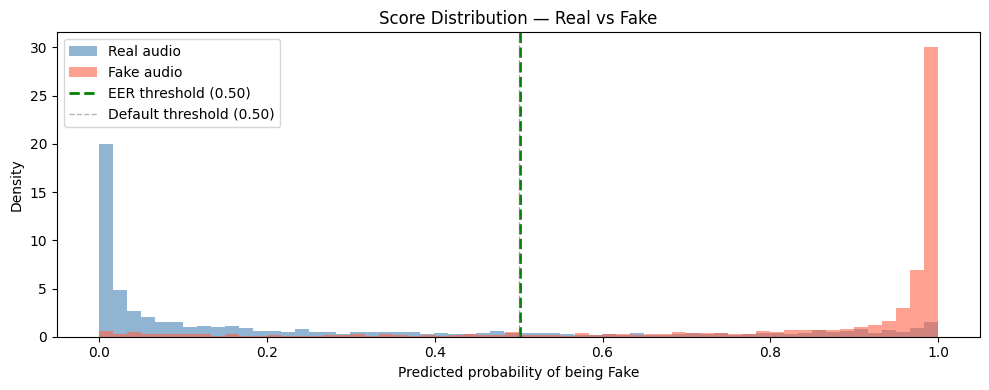

In [23]:
#  Visualize score 
import matplotlib.pyplot as plt

real_scores = y_scores[y_true == 0]
fake_scores = y_scores[y_true == 1]

plt.figure(figsize=(10, 4))
plt.hist(real_scores, bins=60, alpha=0.6, color='steelblue', 
         label='Real audio', density=True)
plt.hist(fake_scores, bins=60, alpha=0.6, color='tomato',    
         label='Fake audio', density=True)
plt.axvline(x=eer_thresh, color='green',  linestyle='--', 
            linewidth=2, label=f'EER threshold ({eer_thresh:.2f})')
plt.axvline(x=0.5,        color='gray',   linestyle='--', 
            linewidth=1, label='Default threshold (0.50)', alpha=0.6)
plt.xlabel('Predicted probability of being Fake')
plt.ylabel('Density')
plt.title('Score Distribution — Real vs Fake')
plt.legend()
plt.tight_layout()
plt.show()

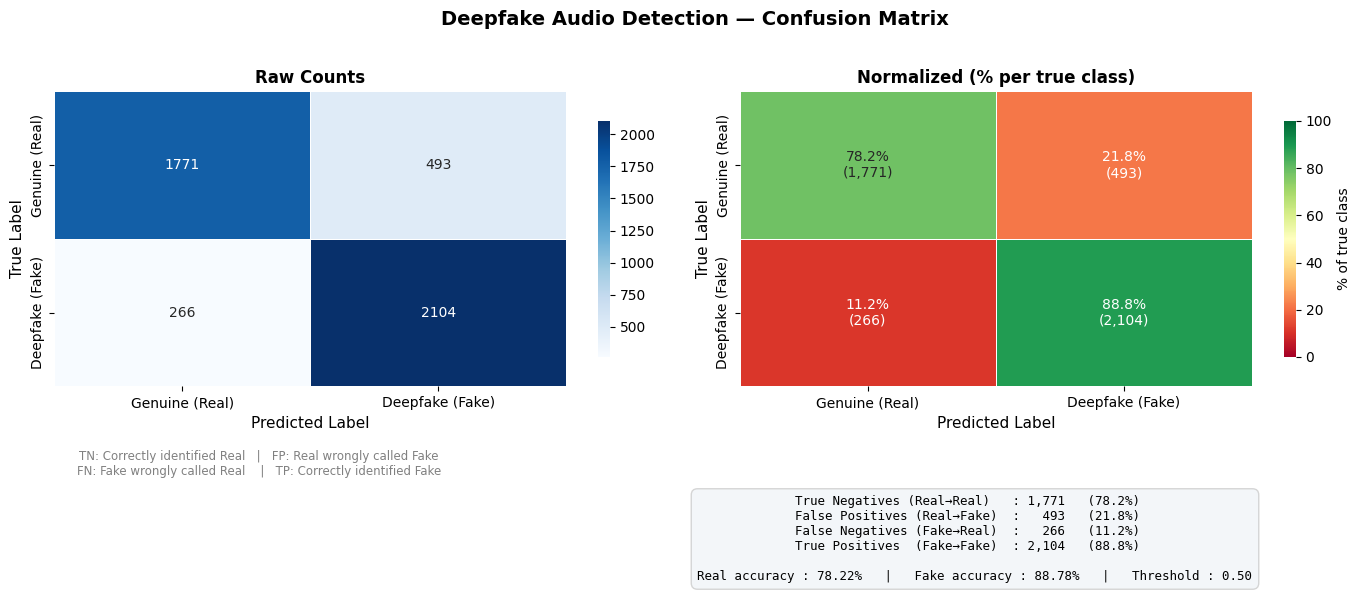

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix


cm       = confusion_matrix(y_true, y_pred)
real_acc = cm[0,0] / cm[0].sum() * 100
fake_acc = cm[1,1] / cm[1].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Deepfake Audio Detection — Confusion Matrix", 
             fontsize=14, fontweight="bold", y=1.02)

#  Raw counts 
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Genuine (Real)", "Deepfake (Fake)"],
    yticklabels=["Genuine (Real)", "Deepfake (Fake)"],
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Raw Counts", fontsize=12, fontweight="bold")
axes[0].set_ylabel("True Label",      fontsize=11)
axes[0].set_xlabel("Predicted Label", fontsize=11)

# Annotate each cell with meaning
axes[0].text(0.4, -0.3,
    f"TN: Correctly identified Real   |   FP: Real wrongly called Fake\n"
    f"FN: Fake wrongly called Real    |   TP: Correctly identified Fake",
    transform=axes[0].transAxes,
    ha="center", fontsize=8.5,
    color="gray"
)

#  Percentage normalized 
cm_pct = cm.astype(float)
cm_pct[0] = cm_pct[0] / cm[0].sum() * 100
cm_pct[1] = cm_pct[1] / cm[1].sum() * 100

labels = np.array([
    [f"{cm_pct[0,0]:.1f}%\n({cm[0,0]:,})", f"{cm_pct[0,1]:.1f}%\n({cm[0,1]:,})"],
    [f"{cm_pct[1,0]:.1f}%\n({cm[1,0]:,})", f"{cm_pct[1,1]:.1f}%\n({cm[1,1]:,})"]
])

sns.heatmap(
    cm_pct,
    annot=labels,
    fmt="",
    cmap="RdYlGn",
    ax=axes[1],
    xticklabels=["Genuine (Real)", "Deepfake (Fake)"],
    yticklabels=["Genuine (Real)", "Deepfake (Fake)"],
    linewidths=0.5,
    linecolor="white",
    vmin=0, vmax=100,
    cbar_kws={"shrink": 0.8, "label": "% of true class"}
)
axes[1].set_title("Normalized (% per true class)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("True Label",      fontsize=11)
axes[1].set_xlabel("Predicted Label", fontsize=11)

# 
summary = (
    f"True Negatives (Real→Real)   : {cm[0,0]:>5,}   ({cm_pct[0,0]:.1f}%)  \n"
    f"False Positives (Real→Fake)  : {cm[0,1]:>5,}   ({cm_pct[0,1]:.1f}%)  \n"
    f"False Negatives (Fake→Real)  : {cm[1,0]:>5,}   ({cm_pct[1,0]:.1f}%)  \n"
    f"True Positives  (Fake→Fake)  : {cm[1,1]:>5,}   ({cm_pct[1,1]:.1f}%)  \n\n"
    f"Real accuracy : {real_acc:.2f}%   |   Fake accuracy : {fake_acc:.2f}%   |   Threshold : {eer_thresh:.2f}"
)
fig.text(0.7, -0.12, summary, ha="center", fontsize=9,
         fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f4f8", 
                   edgecolor="#cccccc", alpha=0.8))

plt.tight_layout()
plt.show()

In [25]:
# Save model configuration and deployment settings:
# - Classification threshold
# - Sample rate
# - Audio duration
# - Model name
# - Class labels
# Enables reproducible inference during deployment.


import json

config = {
    "threshold"   : float(eer_thresh),
    "sample_rate" : 16000,
    "duration"    : 4.0,
    "model"       : "facebook/wav2vec2-base",
    "labels"      : {"0": "Genuine (Real)", "1": "Deepfake (AI-Generated)"}
}
with open("/kaggle/working/config.json", "w") as f:
    json.dump(config, f, indent=2)

print(json.dumps(config, indent=2))

{
  "threshold": 0.5015158788192355,
  "sample_rate": 16000,
  "duration": 4.0,
  "model": "facebook/wav2vec2-base",
  "labels": {
    "0": "Genuine (Real)",
    "1": "Deepfake (AI-Generated)"
  }
}


# Conclusion 

## This project demonstrates how modern speech AI can be used to tackle the growing challenge of deepfake audio detection. By combining robust audio preprocessing with pretrained Wav2Vec2 embeddings, the model is able to capture meaningful speech patterns and distinguish between genuine and AI-generated recordings. The evaluation results show that the system performs reliably on unseen test data, achieving strong accuracy and classification performance. The use of EER and confusion matrix analysis provides a deeper understanding of the model's strengths and limitations. Overall, the project highlights the effectiveness of transfer learning for building practical and scalable solutions for audio authenticity verification.